In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import boxcox
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

## Introduction

This project uses the SPY ETF, which tracks the S&P 500, the main stock market index in the United States. It also uses the ASHR ETF, which tracks the CSI 300, the primary index in China. The objective is to compare the two markets and identify potential correlations. For forecasting with ARIMA, only SPY ETF will be used. For forecasting with GARCH, both will be use to provide hedging opportunities.

## Data Cleaning & Preprocessing
Check for NaN values, datetime object, different operating hours and normalizing to compare returns.

In [2]:
def download(ticker, start, end):
    df = yf.download(ticker, start=start, end=end)
    return df

start_date = "2024-06-01"
end_date = "2025-04-01"

us = download("SPY", start_date, end_date)
china = download("ASHR", start_date, end_date)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


### Handles Missing Values

In [3]:
print(f"US Data type: {us.index.dtype}")
print(f"China Data type: {china.index.dtype}")

mv = us.isnull().Close.sum()
mv2 = china.isnull().Close.sum()
print(f"NaN data: {mv.SPY}")
print(f"NaN data: {mv2.ASHR}")

US Data type: datetime64[s]
China Data type: datetime64[s]
NaN data: 0
NaN data: 0


### Resampling the Data

The US (SPY) might have different trading days compared to China (ASHR). This can be checked by comparing datetime objects.

In [4]:
print(f"Do US and China ETF data have the same index?: {us.index.equals(china.index)}")

Do US and China ETF data have the same index?: True


### Normalizing the Data

Since the price range for the SPY ETF is 523.91 to 531.16, and for the ASHR ETF is 25.48 to 25.65, normalization is necessary for a clearer visual comparison.

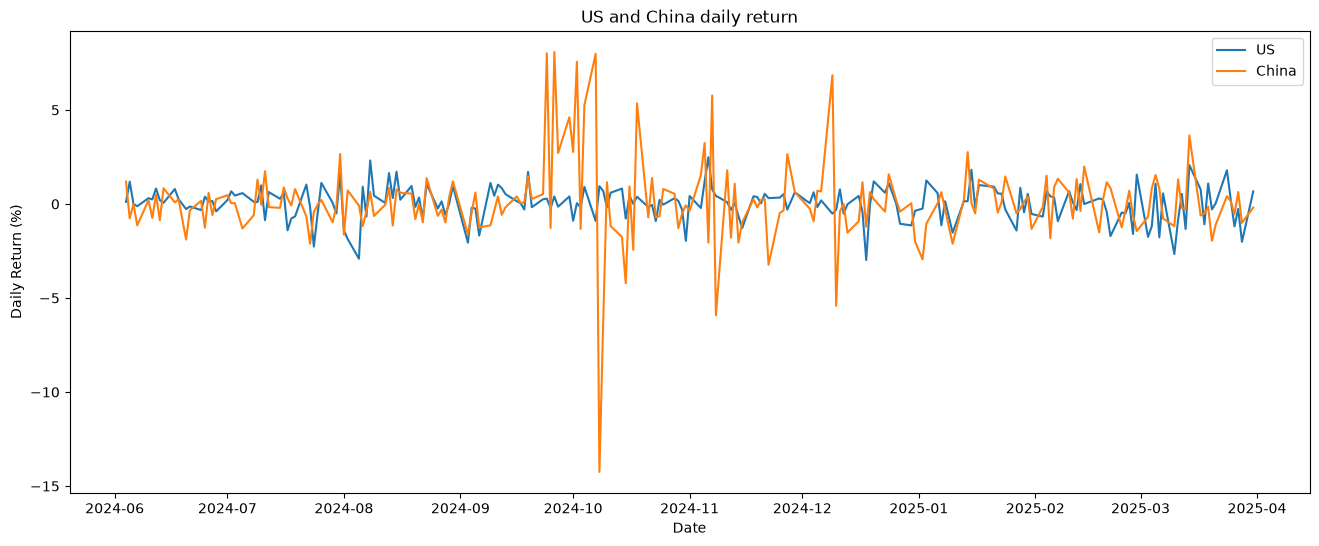

In [26]:
us["daily_return"] = us["Close"].pct_change() * 100
us.dropna(inplace=True) # drop first NaN
china["daily_return"] = china["Close"].pct_change() * 100
china.dropna(inplace=True) # drop first NaN

fig, ax = plt.subplots(figsize=(16,6))
us_return = ax.plot(us.index, us["daily_return"], label="US")
china_return = ax.plot(china.index, china["daily_return"], label="China")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Return (%)")
ax.set_title("US and China daily return")
ax.legend()


# The plot shows that China's market is more volatile than the US.
# Clearly, there's seem to be period of much higher volatilty than others --> GARCH can be implement

## Exploratory Data Analysis (EDA) 

The data is split into a 95:5 train-test ratio to improve forecast accuracy. Since an ARIMA model will be used, it is essential to ensure that the data is stationary. In this section, the mean and variance are visualized, and a log-differencing method is applied to achieve stationarity. Furthermore, the Augmented Dickey-Fuller (ADF) test is conducted to test stationarity.

In [6]:
# Split Data into train and test 
us_train = us.iloc[:int(len(us)*0.95)].copy()
us_test = us.iloc[int(len(us)*0.95):].copy()

china_train = china.iloc[:int(len(us)*0.95)].copy()
china_test = china.iloc[int(len(us)*0.95):].copy()

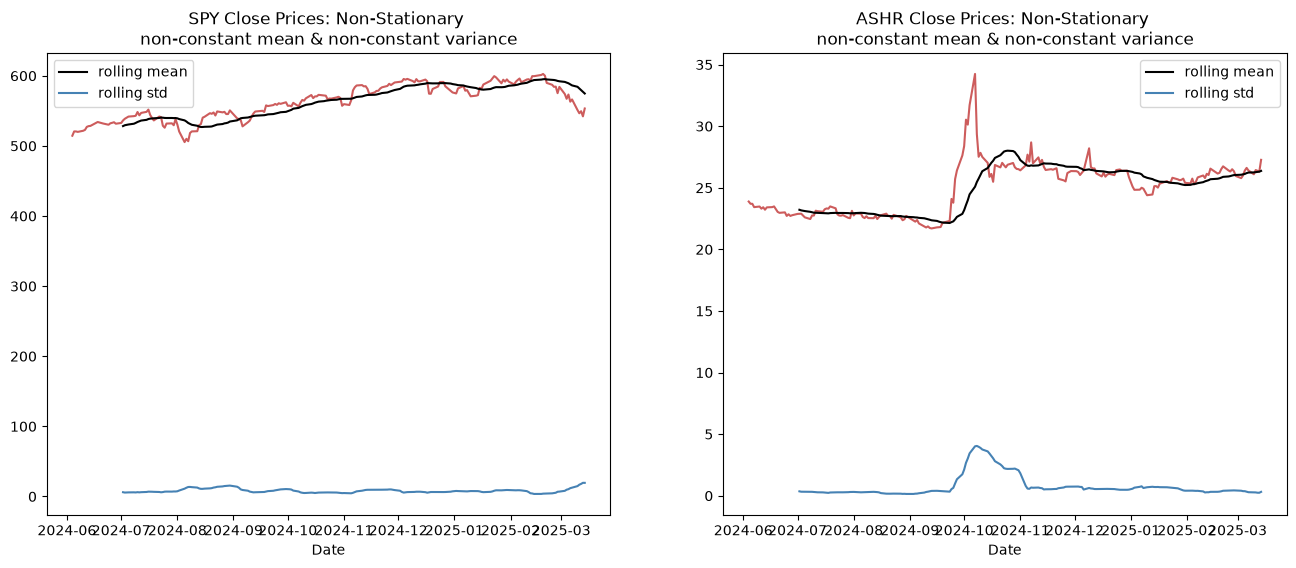

In [7]:
# Visualize check: mean and variance
rolling_window = 20

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

# SPY plot
axes[0].set_title("SPY Close Prices: Non-Stationary \nnon-constant mean & non-constant variance")
axes[0].set_xlabel("Date")
axes[0].plot(us_train.Close, color='indianred')
axes[0].plot(us_train.Close.rolling(rolling_window).mean(), color='black', label='rolling mean')
axes[0].plot(us_train.Close.rolling(rolling_window).std(), color='steelblue', label='rolling std')
axes[0].legend()

# ASHR plot
axes[1].set_title("ASHR Close Prices: Non-Stationary \nnon-constant mean & non-constant variance")
axes[1].set_xlabel("Date")
axes[1].plot(china_train.Close, color='indianred')
axes[1].plot(china_train.Close.rolling(rolling_window).mean(), color='black', label='rolling mean')
axes[1].plot(china_train.Close.rolling(rolling_window).std(), color='steelblue', label='rolling std')
axes[1].legend()

# As seen in the plot, the mean for both datasets is not constant. And China's rolling std has a little kink during the last quarter of 2024
# Due to investors pessimistic about China's economy and its tech sector after Xi Jin Ping annoucement about the tech industry back in 2024.

#### Augmented Dickey–Fuller test

If the ADF statistic is below the critical value, the data can be considered stationary with the corresponding level of confidence.

In [8]:
def adf_test(df):
    test_result = adfuller(df)
    print(f"ADF Statistics: {test_result[0]}")
    print(f"P-Values: {test_result[1]}")
    print("Critical Values:")
    for thres, adf_stat in test_result[4].items():
        print(f"{thres}: {adf_stat}")

adf_test(us_train["Close"])
# In this case, the p-value is higher than the significance level of 0.1 (10%), 
# failing to reject the null hypothesis and the conclusion that the series is non-stationary (US). The same goes with China

ADF Statistics: -2.0533211947129457
P-Values: 0.2636935999730782
Critical Values:
1%: -3.4645146202692527
5%: -2.8765564361715534
10%: -2.5747745328940375


#### Log-Difference Transformation

Transformations such as logarithms can help to stabilise the variance of a time series. Differencing is required to achieve stationarity by stabilizing the mean. This process has been applied to both the US and China ETFs, and the resulting transformations are presented in the plots below. Note: I tried using the Box-Cox transformation, but it made the data "too stationary" and less useful for visualizing or forecasting ETF prices. So, I switched to log-differencing instead.

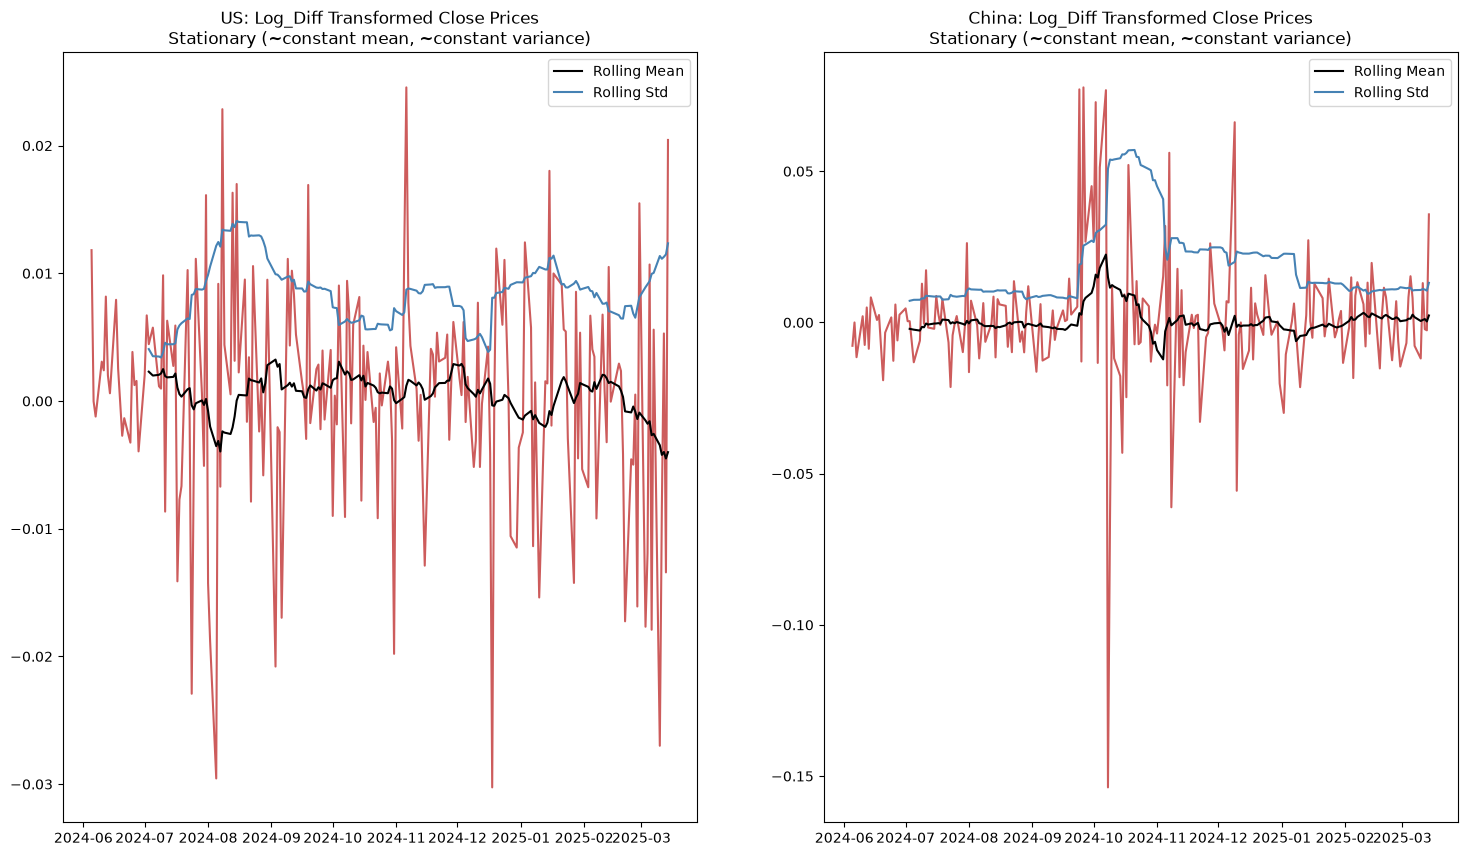

In [9]:
# Log-Difference Transformation
us_train["Close_log"] = np.log(us_train["Close"])
us_train["Close_log_diff"] = us_train["Close_log"].diff()
us_train.dropna(inplace=True) # drop first NaN

china_train["Close_log"] = np.log(china_train["Close"])
china_train["Close_log_diff"] = china_train["Close_log"].diff()
china_train.dropna(inplace=True) # drop first NaN


us_test["Close_log"] = np.log(us_test["Close"])
us_test["Close_log_diff"] = us_test["Close_log"].diff()

fig, axes = plt.subplots(1, 2, figsize=(18, 10), dpi=100)

# US 
axes[0].plot(us_train["Close_log_diff"], color="indianred")
axes[0].plot(us_train["Close_log_diff"].rolling(rolling_window).mean(), color='black', label='Rolling Mean')
axes[0].plot(us_train["Close_log_diff"].rolling(rolling_window).std(), color='steelblue', label='Rolling Std')
axes[0].set_title('US: Log_Diff Transformed Close Prices\nStationary (~constant mean, ~constant variance)')
axes[0].legend()

# China 
axes[1].plot(china_train["Close_log_diff"], color="indianred")
axes[1].plot(china_train["Close_log_diff"].rolling(rolling_window).mean(), color='black', label='Rolling Mean')
axes[1].plot(china_train["Close_log_diff"].rolling(rolling_window).std(), color='steelblue', label='Rolling Std')
axes[1].set_title('China: Log_Diff Transformed Close Prices\nStationary (~constant mean, ~constant variance)')
axes[1].legend()

In [10]:
# Now, let's check the ADF test again
print("US:")
adf_test(us_train["Close_log_diff"])
print("\n")
print("China:")
adf_test(china_train["Close_log_diff"])

# Now the p-values ~ 0 -> reject the hypothesis and conclude that the data is stationary

US:
ADF Statistics: -7.587047589536783
P-Values: 2.5900856930766753e-11
Critical Values:
1%: -3.4652439354133255
5%: -2.8768752281673717
10%: -2.574944653739612


China:
ADF Statistics: -5.722673714509382
P-Values: 6.883583883124343e-07
Critical Values:
1%: -3.466005071659723
5%: -2.8772078537639385
10%: -2.5751221620996647


#### Autocorrelation & Partial Autocorrelation

Since ARIMA = AR + I + MA (Autoregressive + Integrated + Moving Average): AR represents a forecasting model that uses a linear combination of previous values. We need to determine how many past (lagged) values are used. We represents the number of differencing operations required to make the time series stationary. MA represents a moving average that uses past forecast errors instead of the actual previous values. We also need to determine how many past forecast errors are used.

The autoregressive and moving average lagged value can be found by analyzing the partial autocorrelation function (PACF) and the autocorrelation function (ACF), respectively. The idea behind this is to plot a correlogram of the various lags or forecast errors of the time series to determine which are statistically significant.

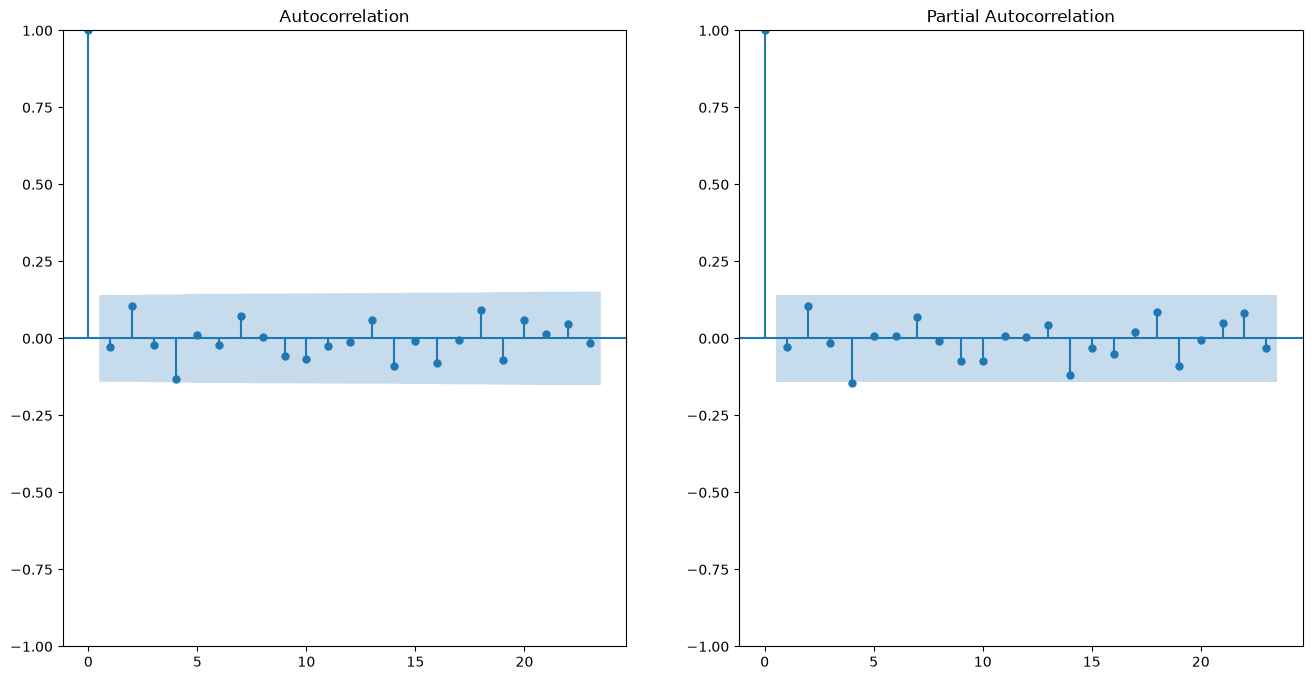

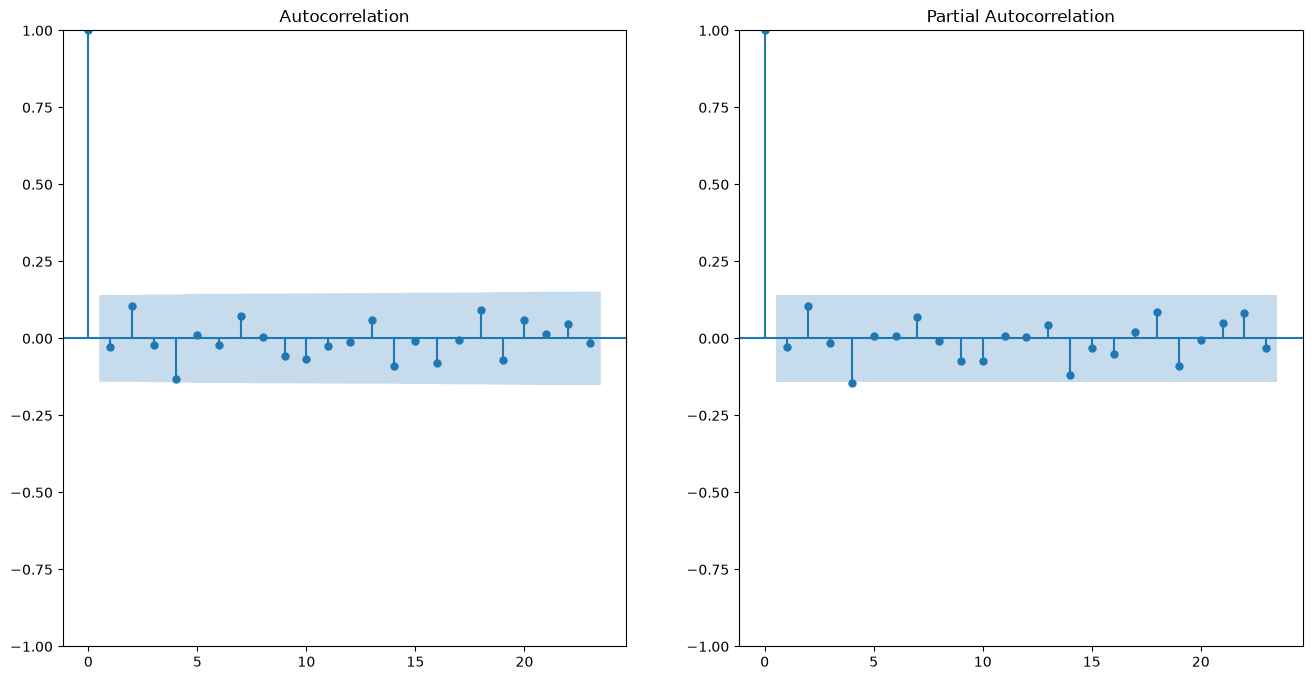

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

plot_acf(us_train["Close_log_diff"], ax=ax1)
plot_pacf(us_train["Close_log_diff"], method="ywm", ax=ax2,)

# if the data is in the blue regioin that means it's no longer statistically significant for the next forecast

## Statistical Modeling or Forecasting


#### ARIMA

In [12]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(us_train["Close_log"], order=(4,1,4)) # Already applied differencing for us with I = 1 
model_fit = model.fit()
print(model_fit.summary())

# Lower AIC via higher log likelihood or less parameter (more simple) -> Model that fit the value well and have less parameter
# Lower BIC vis less samples used in fitting

                               SARIMAX Results                                
Dep. Variable:              Close_log   No. Observations:                  194
Model:                 ARIMA(4, 1, 4)   Log Likelihood                 641.658
Date:                Tue, 04 Aug 2026   AIC                          -1265.316
Time:                        21:57:40   BIC                          -1235.952
Sample:                             0   HQIC                         -1253.425
                                - 194                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4406      0.403     -1.094      0.274      -1.230       0.349
ar.L2         -0.2046      0.325     -0.630      0.529      -0.841       0.432
ar.L3         -0.5670      0.274     -2.069      0.0

/opt/anaconda3/envs/finance/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/finance/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/finance/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


#### Residuals Plot

<Axes: title={'center': 'Density'}, ylabel='Density'>

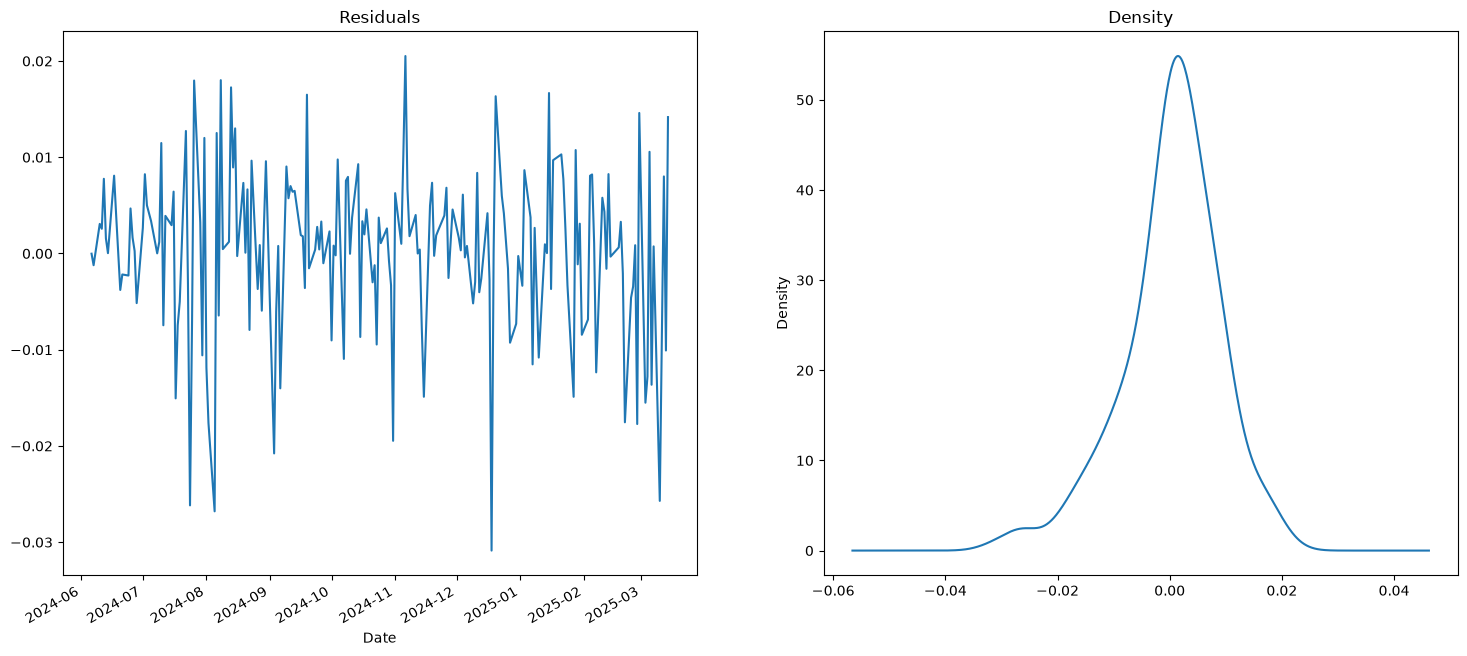

In [13]:
residuals = model_fit.resid[1:]
fig, ax = plt.subplots(1, 2, figsize=(18, 8))
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(title="Density", kind="kde", ax=ax[1])

# if the Model is good the residuals should looks like noise 
# The Residuals look random in general and the density look normal distribution like
# Can also looks ACF and PACF of the residuals

/opt/anaconda3/envs/finance/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/envs/finance/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


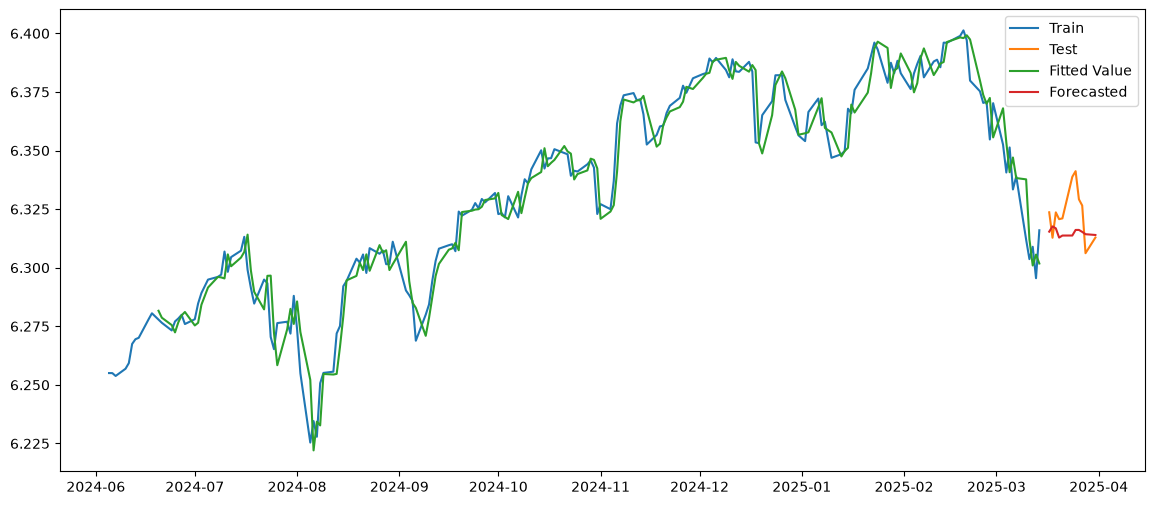

In [14]:
# forecast the test set 
forecast_test = model_fit.forecast(len(us_test))
fitted_us = model_fit.predict()

fig, ax = plt.subplots(figsize=(14, 6))
lines_us_train = ax.plot(us_train.index, us_train["Close_log"], label="Train")
lines_us_test = ax.plot(us_test.index, us_test["Close_log"], label="Test")
lines_us_fitted = ax.plot(us_train.index[10:], fitted_us[10:], label="Fitted Value")
lines_forecasted = ax.plot(us_test.index, forecast_test, label="Forecasted")
ax.legend()

#### Model Performance

In [15]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

mae = mean_absolute_error(us_test["Close_log"], forecast_test)
mape = mean_absolute_percentage_error(us_test["Close_log"], forecast_test)
rmse = np.sqrt(mean_squared_error(us_test["Close_log"], forecast_test))
print(mae, mape, rmse)

0.010796564405472527 0.0017057999789960164 0.01305676098093864


#### GARCH

Comparing historical volatility with return percentages, and then forecasting volatility, in hopes of gaining insight from their past relationship. GARCH is a gerneralization from ARCH which is an Autoregresive model for conditional volatility. 

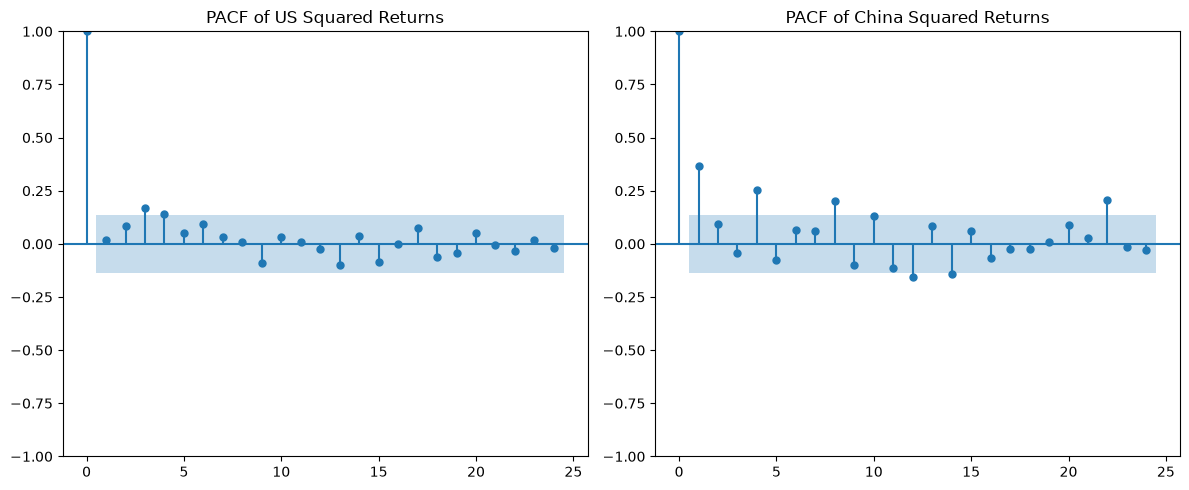

In [17]:
from arch import arch_model

# What lagged should we use? (Same as ARIMA since GARCH is just a Generalized AR with conditional volatility )

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PACF for US variance 
plot_pacf(us["daily_return"]**2, ax=axes[0])
axes[0].set_title("PACF of US Squared Returns")

# PACF for China variance
plot_pacf(china["daily_return"]**2, ax=axes[1])
axes[1].set_title("PACF of China Squared Returns")

plt.tight_layout()
plt.show()
# US: Strong up until lagged 3 -> GARCH(3,3)
# China: Strong up until lagged 2 -> GARCH(2,2) 

In [18]:
us_garch_model = arch_model(us["daily_return"], p=3, q=3)
us_garch_model_fit = us_garch_model.fit(disp="off") # I don't want to print the optimization details. Already too much text
us_garch_model_fit.summary()
# none of the betas are strong for this model (P-values are much more higher than 0) 
# We can drop them and still be statistically be confident with our model

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:           daily_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -262.568
Distribution:                  Normal   AIC:                           541.137
Method:            Maximum Likelihood   BIC:                           567.760
                                        No. Observations:                  206
Date:                Tue, Aug 04 2026   Df Residuals:                      205
Time:                        21:58:31   Df Model:                            1
                                 Mean Model                                
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0522  5.494e-02      0.951      0.342 [-5.546e-02,  0.160]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1196  8.244e-02      1.451      0.147 [-4.196e-02,  0.281]
alpha[1]       0.0000      0.129      0.000      1.000    [ -0.254,  0.254]
alpha[2]       0.0311      0.147      0.212      0.832    [ -0.257,  0.319]
alpha[3]       0.1551  8.369e-02      1.854  6.378e-02 [-8.894e-03,  0.319]
beta[1]        0.6786      0.795      0.854      0.393    [ -0.879,  2.237]
beta[2]        0.0000      0.890      0.000      1.000    [ -1.745,  1.745]
beta[3]        0.0000      0.381      0.000      1.000    [ -0.747,  0.747]
===========================================================================

Covariance estimator: robust
"""

In [19]:
china_garch_model = arch_model(china["daily_return"], p=2, q=2)
china_garch_model_fit = china_garch_model.fit(disp="off")
china_garch_model_fit.summary() 

# Same as US. We can drop all betas since it's not statistically matter.

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:           daily_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -398.689
Distribution:                  Normal   AIC:                           809.379
Method:            Maximum Likelihood   BIC:                           829.346
                                        No. Observations:                  206
Date:                Tue, Aug 04 2026   Df Residuals:                      205
Time:                        21:58:32   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -0.0413     14.414 -2.863e-03      0.998 [-28.293, 28.210]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.9632    235.514  4.090e-03      0.997 [-4.606e+02,4.626e+02]
alpha[1]       0.2713     31.238  8.686e-03      0.993      [-60.954, 61.497]
alpha[2]       0.0815     34.912  2.335e-03      0.998      [-68.344, 68.507]
beta[1]        0.3885    315.947  1.230e-03      0.999 [-6.189e+02,6.196e+02]
beta[2]    5.1411e-17    178.418  2.882e-19      1.000 [-3.497e+02,3.497e+02]
=============================================================================

Covariance estimator: robust
"""

#### Trying out different Model

Drop all the betas (ie. q=0)

In [20]:
us_garch_model = arch_model(us["daily_return"], p=3, q=0)
us_garch_model_fit = us_garch_model.fit(disp="off")
us_garch_model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:           daily_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -267.139
Distribution:                  Normal   AIC:                           544.278
Method:            Maximum Likelihood   BIC:                           560.917
                                        No. Observations:                  206
Date:                Tue, Aug 04 2026   Df Residuals:                      205
Time:                        21:58:34   Df Model:                            1
                                 Mean Model                                
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0403  6.296e-02      0.640      0.522 [-8.308e-02,  0.164]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.6081      0.196      3.109  1.876e-03    [  0.225,  0.991]
alpha[1]   1.4759e-15      0.294  5.019e-15      1.000    [ -0.576,  0.576]
alpha[2]       0.1189      0.130      0.915      0.360    [ -0.136,  0.373]
alpha[3]       0.1397  8.256e-02      1.692  9.058e-02 [-2.210e-02,  0.302]
===========================================================================

Covariance estimator: robust
"""

In [21]:
china_garch_model = arch_model(china["daily_return"], p=2, q=0)
china_garch_model_fit = china_garch_model.fit(disp="off")
china_garch_model_fit.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:           daily_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -399.980
Distribution:                  Normal   AIC:                           807.961
Method:            Maximum Likelihood   BIC:                           821.272
                                        No. Observations:                  206
Date:                Tue, Aug 04 2026   Df Residuals:                      205
Time:                        21:58:35   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -0.0353  9.024e-02     -0.391      0.696 [ -0.212,  0.142]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          1.7206      0.548      3.138  1.700e-03    [  0.646,  2.795]
alpha[1]       0.4048      0.171      2.365  1.802e-02  [6.934e-02,  0.740]
alpha[2]       0.1717  8.853e-02      1.940  5.239e-02 [-1.776e-03,  0.345]
===========================================================================

Covariance estimator: robust
"""

#### GARCH Predictions

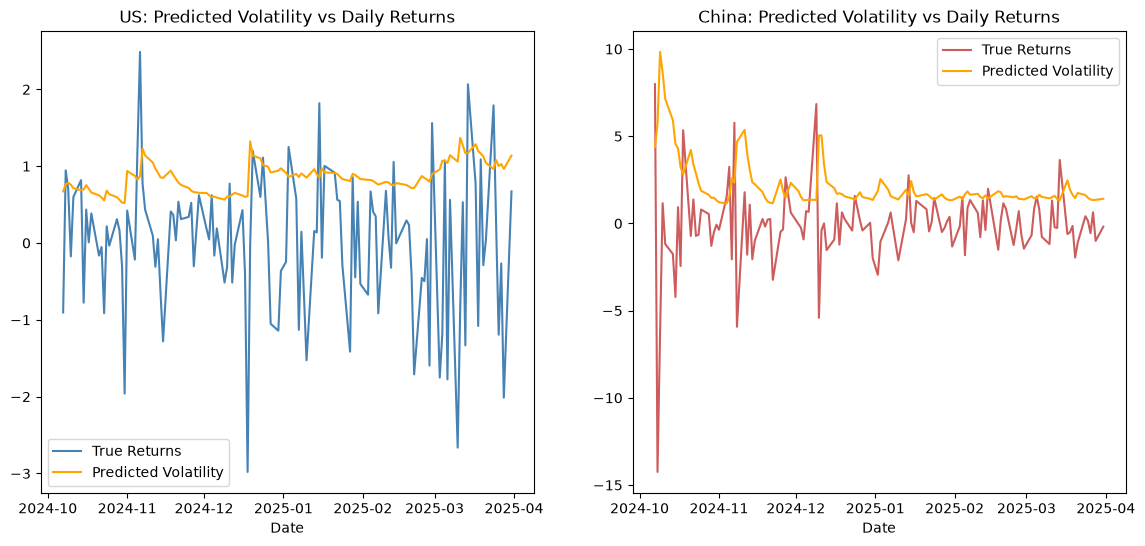

In [38]:
us_rolling_predictions = []
china_rolling_predictions = []
test_size = 120

# train model forecasting each data with horizon 1 in the future then append to our prediction list
def garch_predict(rolling_predictions, test_size, p, q, df):
    for i in range(test_size):
        train = df[:-(test_size-i)] # train up until the start of the 4 month period then keep inserting more data from that
        model = arch_model(train, p=p, q=q)
        model_fit = model.fit(disp="off") # Turn off display, already too much text.
        pred = model_fit.forecast(horizon=1)
        rolling_predictions.append(np.sqrt(pred.variance.values[-1,:][0])) # Volatility ~ sqrt(varinace)

# compute rolling predictions 
garch_predict(us_rolling_predictions, test_size, 1, 1, us["daily_return"])
garch_predict(china_rolling_predictions, test_size, 1, 1, china["daily_return"])

# making sure the index is the same 
us_rolling_series = pd.Series(us_rolling_predictions, index=us["daily_return"].index[-120:])
china_rolling_series = pd.Series(china_rolling_predictions, index=china["daily_return"].index[-120:])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(us["daily_return"][-120:], label="True Returns", color="steelblue")
axes[0].plot(us_rolling_series, label="Predicted Volatility", color="orange")
axes[0].set_title("US: Predicted Volatility vs Daily Returns")
axes[0].set_xlabel("Date")
axes[0].legend()

axes[1].plot(china["daily_return"][-120:], label="True Returns", color="indianred")
axes[1].plot(china_rolling_series, label="Predicted Volatility", color="orange")
axes[1].set_title("China: Predicted Volatility vs Daily Returns")
axes[1].set_xlabel("Date")
axes[1].legend()

# Returns fluctuate in response to changes in volatility, and the predicted volatility matches the actual movements of the return percentages.

#### Future Forecast
Forecasting future volatility for the next 7 days

Text(0.5, 0, 'Date')

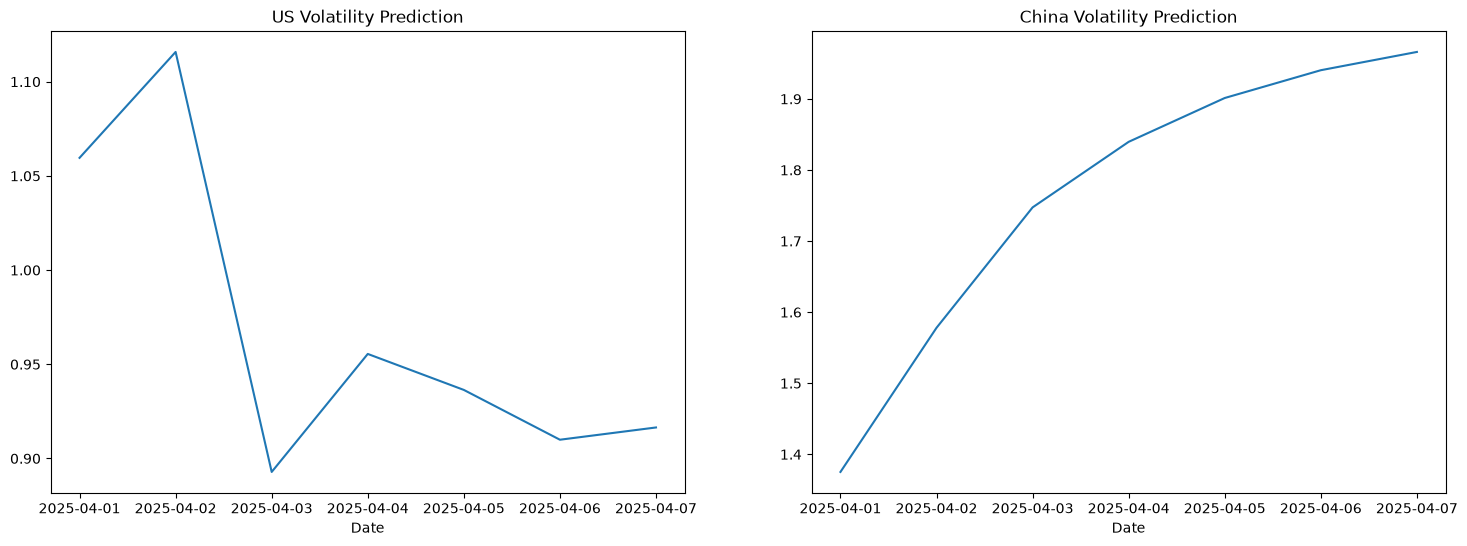

In [39]:
from datetime import datetime, timedelta

# same process but just forecast the next 7 days
us_pred = us_garch_model_fit.forecast(horizon=7) # next 7 days 
china_pred = china_garch_model_fit.forecast(horizon=7)
future_dates = [us["daily_return"].index[-1] + timedelta(days=i) for i in range(1,8)] # Same dates as china

us_pred = pd.Series(np.sqrt(us_pred.variance.values[-1,:]), index=future_dates)
china_pred = pd.Series(np.sqrt(china_pred.variance.values[-1,:]), index=future_dates)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].plot(us_pred)
axes[0].set_title("US Volatility Prediction")
axes[0].set_xlabel("Date")

axes[1].plot(china_pred)
axes[1].set_title("China Volatility Prediction")
axes[1].set_xlabel("Date")

# the movement is somewhat opposite dring this period (2025 start of the trade war between China and US) 

## Insight Generation

From the ARIMA and SARIMA forecasts, it is evident that the models failed to capture the level of market volatility at the beginning of 2025. This period coincided with Trump's inauguration and the introduction of new tariff policies, both of which contributed to increased market uncertainty. The model was unable to account for these events and their impact on volatility. Similarly, if we accept the Efficient Market Hypothesis (EMH) as true, all available information is already priced into the market. That leaves only the random movements to predict.

After switching to a GARCH model, the predictions aligned much more closely with historical volatility compared to the raw returns. By extending the model to forecast future volatility, we observe a negative correlation between changes in volatility for China and the US. This relationship appears to hold accurately only during a specific time window, likely due to the trade tensions between the two countries. Outside of this context, applying the model to gain a consistent edge may be difficult, as the evidence for a strong or persistent correlation is limited.

#### Strategy based on Findings

The strategy involves forecasting next-day volatility for US and China using GARCH(p, q), predicting the next-day log price level with ARIMA(p, 1, q), and analyzing cross-market correlation via PCA on a basket of closing prices. For improved performance, future implementations could use LSTM networks with cross-validation for a better price-level forecasting accuracy. Note: KPSS test is also something that should be look into